In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("job_salary_prediction_dataset.csv")

In [3]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [4]:
df.shape

(250000, 10)

In [7]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [23]:
df['job_title'].unique()

array(['AI Engineer', 'Data Analyst', 'Frontend Developer',
       'Business Analyst', 'Product Manager', 'Backend Developer',
       'Machine Learning Engineer', 'DevOps Engineer',
       'Software Engineer', 'Cybersecurity Analyst', 'Data Scientist',
       'Cloud Engineer'], dtype=object)

In [24]:
import matplotlib.pyplot as plt

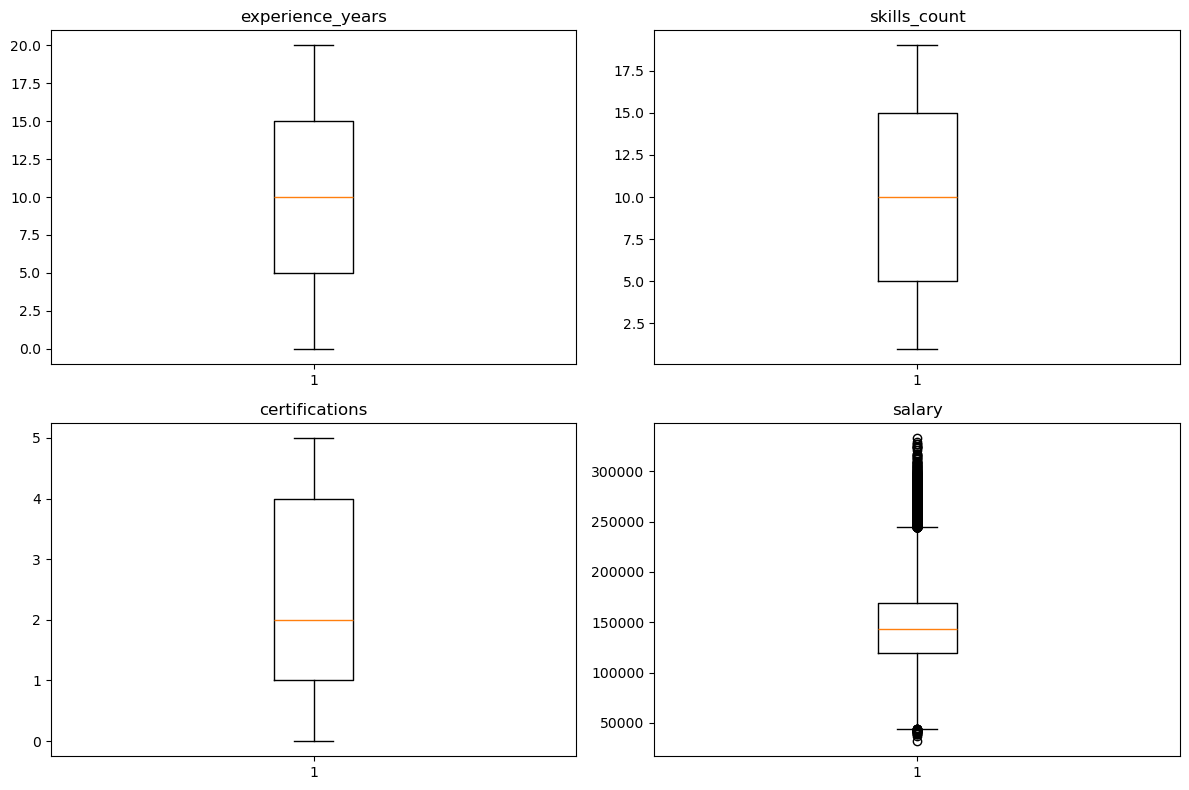

In [28]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.boxplot(df["experience_years"])
plt.title("experience_years")
plt.subplot(2, 2, 2)
plt.boxplot(df["skills_count"])
plt.title("skills_count")
plt.subplot(2, 2, 3)
plt.boxplot(df["certifications"])
plt.title("certifications")
plt.subplot(2, 2, 4)
plt.boxplot(df["salary"])
plt.title("salary")
plt.tight_layout()
plt.show()

In [32]:
df.sort_values('salary', ascending=False).head(10)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
240392,AI Engineer,20,PhD,11,Consulting,Enterprise,USA,Yes,4,333046
177309,AI Engineer,19,PhD,10,Government,Enterprise,USA,No,5,328616
228928,AI Engineer,18,PhD,16,Technology,Enterprise,USA,Hybrid,5,327217
182335,AI Engineer,17,PhD,18,Manufacturing,Enterprise,USA,Hybrid,5,327025
112992,AI Engineer,19,PhD,17,Manufacturing,Enterprise,USA,No,0,325052
50683,AI Engineer,20,PhD,4,Telecom,Enterprise,USA,Yes,4,324583
5971,AI Engineer,19,PhD,16,Consulting,Enterprise,USA,Yes,1,324505
241267,AI Engineer,18,PhD,15,Telecom,Enterprise,USA,No,4,323985
236878,AI Engineer,18,PhD,16,Telecom,Enterprise,USA,No,5,323423
73065,AI Engineer,17,PhD,16,Retail,Enterprise,USA,Yes,3,321127


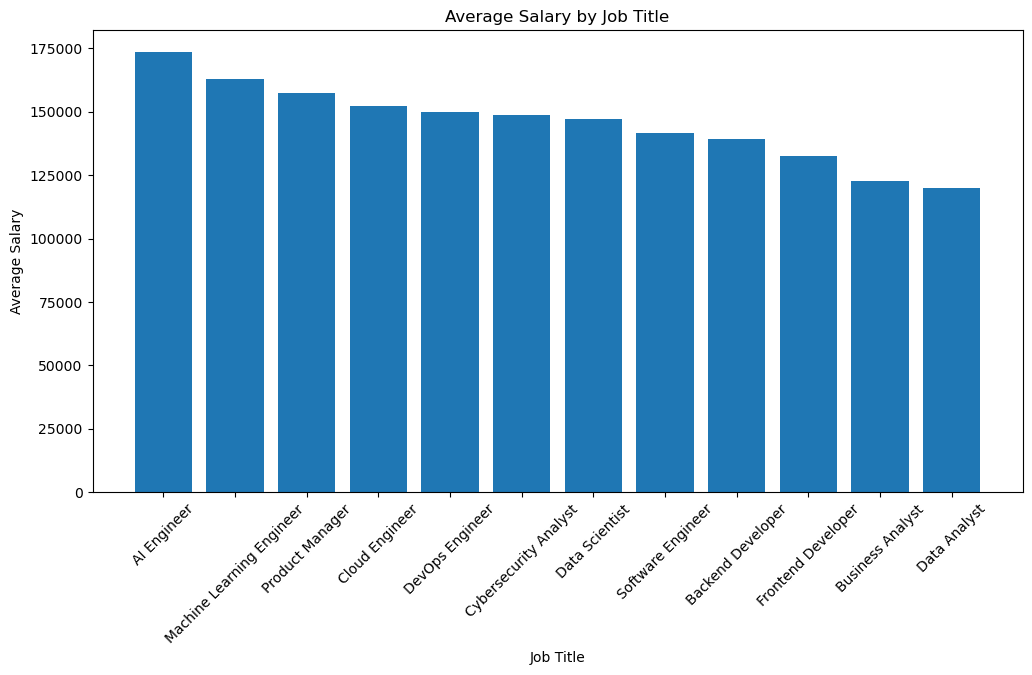

In [35]:
avg_salary_job = df.groupby('job_title')['salary'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
plt.bar(avg_salary_job.index, avg_salary_job.values)

plt.xlabel('Job Title')
plt.ylabel('Average Salary')
plt.title('Average Salary by Job Title')

plt.xticks(rotation=45)
plt.show()

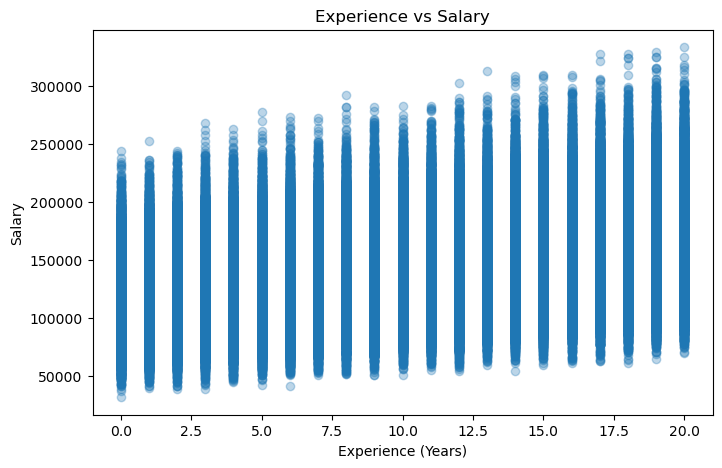

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['experience_years'], df['salary'], alpha=0.3)
plt.xlabel('Experience (Years)')
plt.ylabel('Salary')
plt.title('Experience vs Salary')
plt.show()

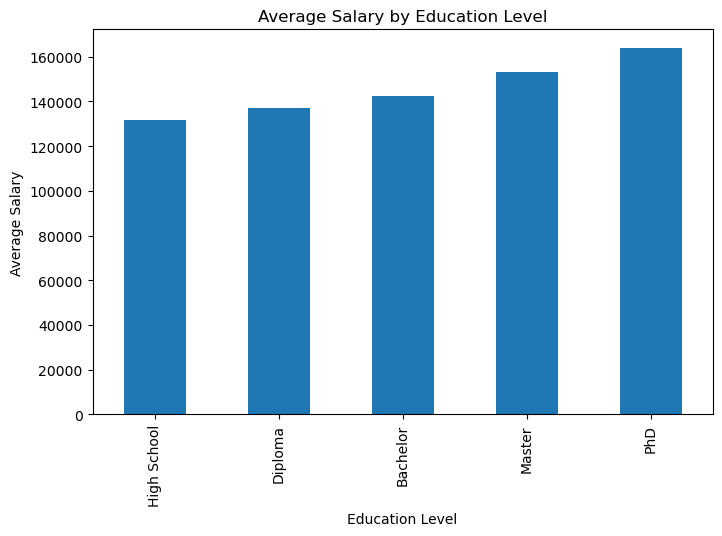

In [40]:
df.groupby('education_level')['salary'].mean().sort_values().plot(
    kind='bar', figsize=(8,5)
)

plt.xlabel('Education Level')
plt.ylabel('Average Salary')
plt.title('Average Salary by Education Level')
plt.show()

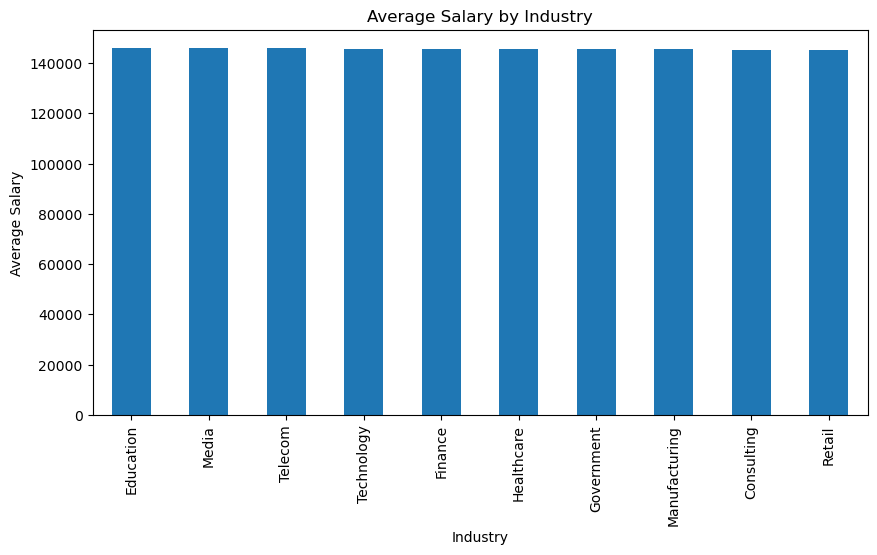

In [41]:
df.groupby('industry')['salary'].mean().sort_values(ascending=False).plot(
    kind='bar', figsize=(10,5)
)

plt.xlabel('Industry')
plt.ylabel('Average Salary')
plt.title('Average Salary by Industry')
plt.show()

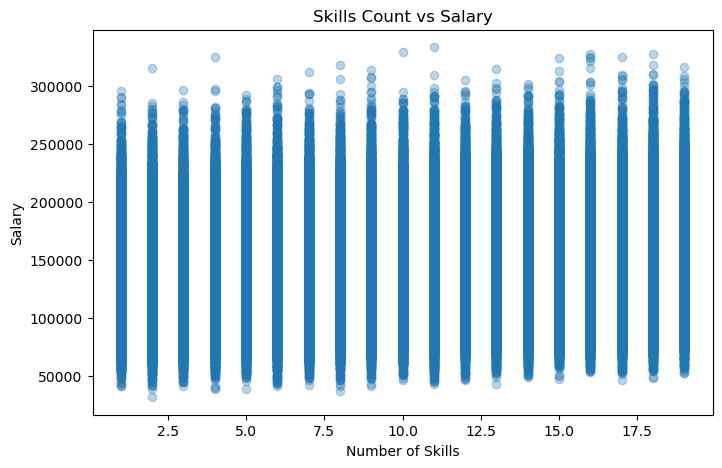

In [42]:
plt.figure(figsize=(8,5))
plt.scatter(df['skills_count'], df['salary'], alpha=0.3)
plt.xlabel('Number of Skills')
plt.ylabel('Salary')
plt.title('Skills Count vs Salary')
plt.show()

In [43]:
X=df.drop("salary",axis=1)
y=df['salary']

In [51]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [55]:
X_train_encoded = encoder.fit_transform(X_train[categorical_cols])

In [59]:
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_train.index
)

In [61]:
X_train_final = pd.concat([X_train[numerical_cols], X_train_encoded], axis=1)

In [63]:
X_train_final.shape

(200000, 48)

In [64]:
X_test.shape

(50000, 9)

In [65]:
X_test_encoded = encoder.transform(X_test[categorical_cols])

In [67]:
X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_test.index
)

In [69]:
X_test_final = pd.concat([X_test[numerical_cols], X_test_encoded], axis=1)

In [71]:
X_test_final.shape

(50000, 48)

In [85]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV


param_dist = {
    'n_estimators': [100, 150, 200, 250],
    'max_depth': [10, 15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10, 20, 50],
    'min_samples_leaf': [1, 2, 5, 10, 50],
    'max_features': ['sqrt', 'log2', 0.5, 0.8]
}

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1 #use all available CPU cores
)

In [86]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

In [87]:
random_search.fit(X_train_final, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [10, 15, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,15
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [92]:
print("Best Parameters:")
print(random_search.best_params_)

print("Best CV R2:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.8, 'max_depth': 20}
Best CV R2:
0.9629904808516564


In [93]:
best_rf = random_search.best_estimator_

In [94]:
y_pred = best_rf.predict(X_test_final)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 5574.18128564861
RMSE: 7015.231274153021
R2: 0.9645911522316146


In [95]:
print("Training R2:", best_rf.score(X_train_final, y_train))
print("Testing R2:", best_rf.score(X_test_final, y_test))

Training R2: 0.9768408728404817
Testing R2: 0.9645911522316146


In [96]:
#saving the parameters
import joblib

joblib.dump(encoder, 'salary_encoder.pkl')
joblib.dump(best_rf, 'salary_prediction_model.pkl')

['salary_prediction_model.pkl']